# Magnitude conversion in xlens: smooth-truncated `flux_to_mag`

xlens pins every measured flux to a **fixed AB zeropoint** `MAG_ZERO_AB = 31.4`
(fluxes are in nanojansky):

$$m_\mathrm{AB} = 31.4 - 2.5\,\log_{10} F_\mathrm{nJy}.$$

The naive formula diverges as $F\to 0^+$ and is undefined for $F\le 0$ (which
noisy forced photometry produces all the time). `xlens.catalog.utils.flux_to_mag`
replaces it with a **smooth, C1-continuous truncation**: it equals the standard
magnitude brighter than a knee `MAG_KNEE = 30`, then a smoothstep blends it toward
a ceiling `MAG_CAP = 40`, which it reaches exactly for `flux <= flux(MAG_CAP)` —
including zero and negative flux. No `log10` of a non-positive number, no
discontinuity at `flux = 0`.

This notebook shows (1) mag vs flux at the 31.4 zeropoint, and (2) the
smooth-truncated magnitude vs the normal magnitude.

In [1]:
import sys
# Use the sandbox xlens (edits here are not installed site-wide).
if "/home/xiangchong/work/detection_study/xlens" not in sys.path:
    sys.path.insert(0, "/home/xiangchong/work/detection_study/xlens")

import numpy as np
import matplotlib.pyplot as plt

from xlens.catalog.utils import flux_to_mag, MAG_KNEE, MAG_CAP
from xlens.utils.constants import MAG_ZERO_AB

print("MAG_ZERO_AB =", MAG_ZERO_AB)
print("MAG_KNEE    =", MAG_KNEE)
print("MAG_CAP     =", MAG_CAP)

MAG_ZERO_AB = 31.4
MAG_KNEE    = 30.0
MAG_CAP     = 40.0


## Helpers

`flux_to_mag` is the smooth-truncated conversion used everywhere in xlens.
For comparison we define the *normal* (textbook) magnitude, which is only
defined for positive flux.

In [2]:
def normal_mag(flux, mag_zero=MAG_ZERO_AB):
    """Textbook AB magnitude: undefined (NaN) for flux <= 0."""
    flux = np.asarray(flux, dtype=float)
    out = np.full_like(flux, np.nan)
    pos = flux > 0
    out[pos] = mag_zero - 2.5 * np.log10(flux[pos])
    return out

# Flux of the knee / cap at this zeropoint (nJy).
flux_knee = 10.0 ** ((MAG_ZERO_AB - MAG_KNEE) / 2.5)
flux_cap  = 10.0 ** ((MAG_ZERO_AB - MAG_CAP) / 2.5)
print(f"flux(MAG_KNEE=30) = {flux_knee:.4g} nJy")
print(f"flux(MAG_CAP =40) = {flux_cap:.4g} nJy")

flux(MAG_KNEE=30) = 3.631 nJy
flux(MAG_CAP =40) = 0.0003631 nJy


## Figure

**Left** — magnitude vs flux at the 31.4 zeropoint. The normal magnitude
(dashed) runs off to $+\infty$ as $F\to0^+$ and stops (it is undefined for
$F\le0$). The smooth-truncated magnitude (solid) tracks it for bright sources,
bends over past the knee, and saturates at the 40 ceiling — remaining finite for
zero and negative flux.

**Right** — the transfer curve: smooth-truncated magnitude vs the normal
magnitude. It is the identity (grey) up to `MAG_KNEE = 30`, then a smoothstep
rolls it onto the `MAG_CAP = 40` ceiling.

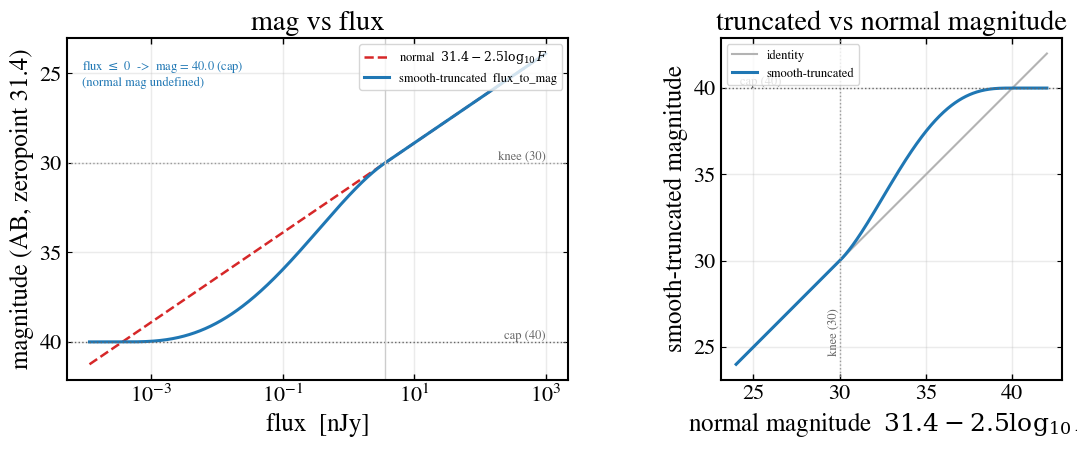

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.8))

# --- Left: mag vs flux (zeropoint 31.4) ---
# span from bright (large flux) down through the knee/cap and into <= 0 flux.
flux_pos = np.logspace(np.log10(flux_cap) - 0.5, 3.0, 600)   # positive flux
m_std = normal_mag(flux_pos)
m_tru, _ = flux_to_mag(flux_pos, MAG_ZERO_AB)

axL.plot(flux_pos, m_std, "--", color="tab:red", lw=1.8,
         label="normal  $31.4 - 2.5\\log_{10}F$")
axL.plot(flux_pos, m_tru, "-", color="tab:blue", lw=2.2,
         label="smooth-truncated  flux_to_mag")

# a couple of non-positive fluxes: normal mag undefined, truncated -> cap
flux_np = np.array([-5.0, -0.5, 0.0])
m_tru_np, _ = flux_to_mag(flux_np, MAG_ZERO_AB)
axL.scatter([flux_cap]*0, [], )  # keep axis autoscale on positive data
axL.axhline(MAG_KNEE, color="0.6", ls=":", lw=1)
axL.axhline(MAG_CAP,  color="0.4", ls=":", lw=1)
axL.text(flux_pos.max(), MAG_KNEE, " knee (30)", va="bottom", ha="right", color="0.4", fontsize=9)
axL.text(flux_pos.max(), MAG_CAP,  " cap (40)",  va="bottom", ha="right", color="0.4", fontsize=9)
axL.axvline(flux_knee, color="0.8", ls="-", lw=1)
axL.set_xscale("log")
axL.set_xlabel("flux  [nJy]")
axL.set_ylabel("magnitude (AB, zeropoint 31.4)")
axL.set_title("mag vs flux")
axL.invert_yaxis()
axL.legend(loc="upper right", fontsize=9)
axL.grid(alpha=0.25)

# annotate the zero/negative-flux behaviour (top-left is empty here)
axL.text(0.03, 0.94,
         f"flux $\\leq$ 0  ->  mag = {m_tru_np[0]:.1f} (cap)\n(normal mag undefined)",
         transform=axL.transAxes, fontsize=9, color="tab:blue",
         va="top", ha="left")

# --- Right: smooth-truncated mag vs normal mag ---
m_normal_axis = np.linspace(24, 42, 600)
flux_from_normal = 10.0 ** ((MAG_ZERO_AB - m_normal_axis) / 2.5)
m_tru_axis, _ = flux_to_mag(flux_from_normal, MAG_ZERO_AB)

axR.plot(m_normal_axis, m_normal_axis, color="0.7", lw=1.5, label="identity")
axR.plot(m_normal_axis, m_tru_axis, color="tab:blue", lw=2.2,
         label="smooth-truncated")
axR.axvline(MAG_KNEE, color="0.6", ls=":", lw=1)
axR.axhline(MAG_CAP,  color="0.4", ls=":", lw=1)
axR.text(MAG_KNEE, 24.3, " knee (30)", rotation=90, va="bottom", ha="right",
         color="0.4", fontsize=9)
axR.text(24.2, MAG_CAP, "cap (40)", va="bottom", ha="left", color="0.4", fontsize=9)
axR.set_xlabel("normal magnitude  $31.4 - 2.5\\log_{10}F$")
axR.set_ylabel("smooth-truncated magnitude")
axR.set_title("truncated vs normal magnitude")
axR.legend(loc="upper left", fontsize=9)
axR.grid(alpha=0.25)
axR.set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()

## Sanity checks

- Bright sources are **unchanged**: below `MAG_KNEE` the truncated magnitude
  equals the normal one to machine precision.
- Zero / negative flux map to the **cap** rather than `NaN`/`inf`.
- The magnitude error stays bounded and well-defined even for `flux <= 0`.

In [4]:
# 1) bright end matches the textbook formula
flux_bright = np.array([10.0, 100.0, 1000.0])   # all brighter than the knee
m_t, _ = flux_to_mag(flux_bright, MAG_ZERO_AB)
m_n = normal_mag(flux_bright)
print("bright flux :", flux_bright)
print("truncated   :", np.round(m_t, 6))
print("normal      :", np.round(m_n, 6))
print("max |diff|  :", np.max(np.abs(m_t - m_n)), "(bright end unchanged)")
print()

# 2) faint / zero / negative flux
flux_edge = np.array([flux_cap, 0.0, -1.0, -10.0])
m_e, me_e = flux_to_mag(flux_edge, MAG_ZERO_AB, flux_err=np.ones_like(flux_edge))
print("edge flux   :", flux_edge)
print("truncated   :", np.round(m_e, 4), "  (-> cap 40, finite)")
print("mag_err     :", np.round(me_e, 4), "  (bounded, no NaN/inf)")
assert np.all(np.isfinite(m_e)) and np.all(np.isfinite(me_e))
print("\nAll finite. OK.")

bright flux : [  10.  100. 1000.]
truncated   : [28.9 26.4 23.9]
normal      : [28.9 26.4 23.9]
max |diff|  : 0.0 (bright end unchanged)

edge flux   : [ 3.63078055e-04  0.00000000e+00 -1.00000000e+00 -1.00000000e+01]
truncated   : [40. 40. 40. 40.]   (-> cap 40, finite)
mag_err     : [2990.3658 2990.3658 2990.3658 2990.3658]   (bounded, no NaN/inf)

All finite. OK.
